# KAGGLE 2: ENSÉÑAME LA PASTA

### ENTRENAMIENTO DE MODELOS

* Logistic regression
* Decision_trees
* SVM: linear y rbf
* Random Forest
* Gradient Boosting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC  # sirve para linear y kernel cambiando el parámetro kernel=
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [6]:
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [3]:
train = pd.read_csv("train_limpio.csv")
test = pd.read_csv("test_limpio.csv")

In [4]:
train.head()

,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
0,9580,1.0,58,1,2.0,3425.0,9,1,1,1,1.0,0
1,118799,0.0,52,1,0.0,5000.0,9,0,0,0,0.0,0
2,16489,0.0,77,0,1.0,2000.0,8,0,0,0,0.0,0
3,149857,1.0,30,0,0.0,5843.0,4,0,0,0,0.0,0
4,6660,0.0,80,0,0.0,10416.0,4,0,0,0,0.0,0


In [5]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=["ID", "SeriousDlqin2yrs"])
y = train["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic regression

In [19]:
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

c:\Users\cchia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [20]:
# A qué clase las ha asignado
pred = model.predict(X_test)
print(pred)

[0 0 0 ... 1 0 1]


In [21]:
# Probabilidades por las que las ha asignado
pred_proba = model.predict_proba(X_test)
print(np.round(np.array(pred_proba), 2))

[[0.8  0.2 ]
 [0.88 0.12]
 [0.76 0.24]
 ...
 [0.1  0.9 ]
 [0.8  0.2 ]
 [0.36 0.64]]


In [23]:
model.score(X_test, y_test) # F1 (métrica combinada entre precisión y recall): el modelo es así así...

0.7936631528509823

Voy a probar escalando...

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train2 = scaler.fit_transform(X_train)
X_test2 = scaler.transform(X_test)

In [25]:
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train2, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [ ]:
# A qué clase las ha asignado
pred = model.predict(X_test2)
print(pred)

# Probabilidades por las que las ha asignado
pred_proba = model.predict_proba(X_test2)
print(np.round(np.array(pred_proba), 2))

model.score(X_test2, y_test) # F1 (métrica combinada entre precisión y recall): no mejora

[0 0 0 ... 1 0 1]
[[0.8  0.2 ]
 [0.88 0.12]
 [0.76 0.24]
 ...
 [0.09 0.91]
 [0.8  0.2 ]
 [0.36 0.64]]


0.7931839961667465

## Decision_trees

In [33]:
tree_clf = DecisionTreeClassifier(max_depth=3,
                                  class_weight="balanced",
                                  random_state=42) 
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [ ]:
# A qué clase las ha asignado
pred = tree_clf.predict(X_test)
print(pred)

# Probabilidades por las que las ha asignado
pred_proba = tree_clf.predict_proba(X_test)
print(np.round(np.array(pred_proba), 2))

tree_clf.score(X_test, y_test) # F1 (métrica combinada entre precisión y recall): el modelo mejora!!

[0 0 0 ... 1 0 0]
[[0.83 0.17]
 [0.83 0.17]
 [0.83 0.17]
 ...
 [0.23 0.77]
 [0.83 0.17]
 [0.5  0.5 ]]


0.8696693818878773

In [ ]:
c_matrix = confusion_matrix(y_test, pred)
c_matrix # se equivoca bastante

array([[13919,  1649],
       [  527,   601]])

In [48]:
# SIN ESCALAR
from sklearn.model_selection import GridSearchCV

# Definir los hiperparámetros a probar
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'class_weight': ["balanced"]
}

# Crear el modelo base
tree2 = DecisionTreeClassifier(random_state=42)

# GridSearch con cross validation (cv=5 → 5 folds)
grid_search = GridSearchCV(
    estimator=tree2,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc', # aquí tengo que meter uno que tenga sentido para CLASIFICAR
    n_jobs=-1,  # usa todos los núcleos del procesador
)

# Entrenar
grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_

# Mejores hiperparámetros encontrados
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor roc_auc:", grid_search.best_score_)

Mejores parámetros: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2}
Mejor roc_auc: 0.8299718087708212


In [50]:
tree_clf = DecisionTreeClassifier(max_depth=5,
                                  min_samples_leaf=8,
                                  min_samples_split=2,
                                  criterion="entropy",
                                  class_weight="balanced",
                                  random_state=42) 
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### De momento...

In [51]:
from sklearn.metrics import roc_auc_score

# Logistic regression sin escalar
pred_proba = model.predict_proba(X_test)[:, 1]
print("Logistic (sin escalar):", roc_auc_score(y_test, pred_proba))

# Logistic regression escalada
pred_proba2 = model.predict_proba(X_test2)[:, 1]
print("Logistic (escalada):", roc_auc_score(y_test, pred_proba2))

# Decision Tree
pred_proba_tree = tree_clf.predict_proba(X_test)[:, 1]
print("Decision Tree:", roc_auc_score(y_test, pred_proba_tree))

# GridSearch best tree
pred_proba_best = best_tree.predict_proba(X_test)[:, 1]
print("Best Tree (GridSearch):", roc_auc_score(y_test, pred_proba_best))

Logistic (sin escalar): 0.5611869831642284
Logistic (escalada): 0.8429491778917293
Decision Tree: 0.8337525932901095
Best Tree (GridSearch): 0.8337525932901095


c:\Users\cchia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


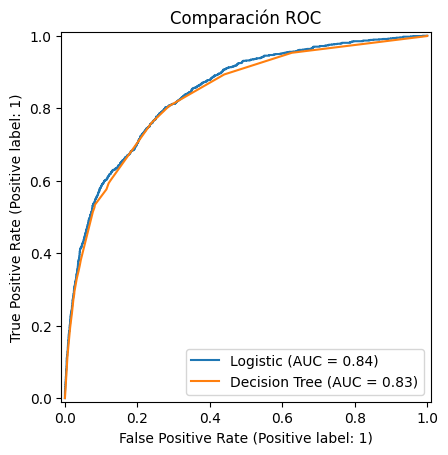

In [52]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test2, y_test, name="Logistic")
RocCurveDisplay.from_estimator(tree_clf, X_test, y_test, name="Decision Tree", ax=plt.gca())
plt.title("Comparación ROC")
plt.show()

## SVM: linear y rbf

In [ ]:
# pruebo directamente con las escaladas por su sensibilidad

In [ ]:
# LINEAR
svm_linear = SVC(kernel='linear', C = 1*10**10, max_iter=1000, class_weight="balanced", random_state=42, probability=True)
svm_linear.fit(X_train2, y_train)

# A qué clase las ha asignado
pred = svm_linear.predict(X_test2)
print(pred)

# Probabilidades por las que las ha asignado
pred_proba = svm_linear.predict_proba(X_test2)
print(np.round(np.array(pred_proba), 2))

svm_linear.score(X_test2, y_test) # F1 (métrica combinada entre precisión y recall): malo

c:\Users\cchia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[0 0 1 ... 1 1 0]
[[0.93 0.07]
 [0.93 0.07]
 [0.93 0.07]
 ...
 [0.93 0.07]
 [0.93 0.07]
 [0.93 0.07]]


0.5200047915668423

In [ ]:
# RBF
svm_rbf = SVC(kernel='rbf', C = 1*10**10, max_iter=1000, class_weight="balanced", random_state=42, probability=True)
svm_rbf.fit(X_train2, y_train)

# A qué clase las ha asignado
pred = svm_rbf.predict(X_test2)
print(pred)

# Probabilidades por las que las ha asignado
pred_proba = svm_rbf.predict_proba(X_test2)
print(np.round(np.array(pred_proba), 2))

svm_rbf.score(X_test2, y_test) # F1 (métrica combinada entre precisión y recall): mejora

c:\Users\cchia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


[0 0 0 ... 0 0 0]
[[0.94 0.06]
 [0.94 0.06]
 [0.94 0.06]
 ...
 [0.94 0.06]
 [0.94 0.06]
 [0.94 0.06]]


0.78941063727839

## Random Forest

In [74]:
from sklearn.model_selection import cross_val_score

rnd_clf = RandomForestClassifier(n_estimators=100,
                                 max_features=3,
                                 max_leaf_nodes=16,
                                 class_weight="balanced",
                                 random_state=42)

rnd_scores = cross_val_score(rnd_clf, X_train, y_train, cv=10, scoring='roc_auc')
print(rnd_scores)
print(rnd_scores.mean())

rnd_clf.fit(X_train, y_train)

# Predicción y métricas
pred_proba_rf = rnd_clf.predict_proba(X_test)[:, 1]
print("Random Forest AUC:", roc_auc_score(y_test, pred_proba_rf)) # NI TAN MAL!!!

# Feature importance
print(rnd_clf.feature_importances_)

[0.84090799 0.8556328  0.84465995 0.84954899 0.85031939 0.82738512
 0.84778665 0.82725841 0.84279265 0.83374063]
0.8420032592618296
Random Forest AUC: 0.8413519184652278
[0.38868615 0.034359   0.21148331 0.01291016 0.01239892 0.00817931
 0.21565436 0.01089541 0.10452043 0.00091295]


In [62]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_distributions=param_grid_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)

random_search_rf.fit(X_train, y_train)
best_rf = random_search_rf.best_estimator_

print("Mejores parámetros:", random_search_rf.best_params_)
print("Mejor roc_auc:", random_search_rf.best_score_)

pred_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]
print("Random Forest (tuned):", roc_auc_score(y_test, pred_proba_best_rf))

Mejores parámetros: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 6}
Mejor roc_auc: 0.8419391383875966
Random Forest (tuned): 0.8420961938655763


In [63]:
from sklearn.model_selection import cross_val_score

rnd_clf = RandomForestClassifier(n_estimators=300,
                                 max_features="log2",
                                 min_samples_split=5,
                                 min_samples_leaf=4,
                                 max_depth=6,
                                 class_weight="balanced",
                                 random_state=42)

rnd_clf.fit(X_train, y_train)

pred_proba_rf = rnd_clf.predict_proba(X_test)[:, 1]
print("Random Forest AUC:", roc_auc_score(y_test, pred_proba_rf)) # NI TAN MAL!!!

Random Forest AUC: 0.8420961938655763


## Gradient Boosting

In [73]:
gbct = GradientBoostingClassifier(max_depth=2,
                                  n_estimators=100,
                                  learning_rate=0.1,
                                  random_state=42)

gbct_scores = cross_val_score(gbct, X_train, y_train, cv=10, scoring='roc_auc')
print(gbct_scores)
print(gbct_scores.mean())

gbct.fit(X_train, y_train)

# Predicción y métricas
pred_proba_gb = gbct.predict_proba(X_test)[:, 1]
print("Gradient Boosting AUC:", roc_auc_score(y_test, pred_proba_gb))

print(gbct.feature_importances_)

# EL MEJOR!!!

[0.84393613 0.86033666 0.84435187 0.85242855 0.85744249 0.82995855
 0.85524414 0.8322832  0.84699846 0.83918185]
0.8462161885881645
Gradient Boosting AUC: 0.8476738461054865
[0.22238073 0.01670662 0.13360457 0.01458918 0.01232561 0.01242971
 0.43322009 0.00951618 0.14359361 0.0016337 ]


In [ ]:
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid_gb,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)

random_search_gb.fit(X_train, y_train)
best_gb = random_search_gb.best_estimator_

print("Mejores parámetros:", random_search_gb.best_params_)
print("Mejor roc_auc:", random_search_gb.best_score_)

pred_proba_best_gb = best_gb.predict_proba(X_test)[:, 1]
print("Gradient Boosting (tuned):", roc_auc_score(y_test, pred_proba_best_gb))

# EMPEORA, me quedo con el anterior

Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.05}
Mejor roc_auc: 0.8459479411609018
Gradient Boosting (tuned): 0.849262706096521


# COMPARACIÓN FINAL:

In [ ]:
from sklearn.metrics import roc_auc_score

# Logistic regression sin escalar
pred_proba = model.predict_proba(X_test)[:, 1]
print("Logistic (sin escalar):", roc_auc_score(y_test, pred_proba))

# Logistic regression escalada
pred_proba2 = model.predict_proba(X_test2)[:, 1]
print("Logistic (escalada):", roc_auc_score(y_test, pred_proba2))

# Decision Tree
pred_proba_tree = tree_clf.predict_proba(X_test)[:, 1]
print("Decision Tree:", roc_auc_score(y_test, pred_proba_tree))

# GridSearch best tree
pred_proba_best = best_tree.predict_proba(X_test)[:, 1]
print("Best Tree (GridSearch):", roc_auc_score(y_test, pred_proba_best))

# SVM linear
pred_proba_svm_linear = svm_linear.predict_proba(X_test2)[:, 1]
print("SVM linear:", roc_auc_score(y_test, pred_proba_svm_linear))

# SVM rbf
pred_proba_svm_rbf = svm_rbf.predict_proba(X_test2)[:, 1]
print("SVM rbf:", roc_auc_score(y_test, pred_proba_svm_rbf))

# Random Forest
pred_proba_rf = rnd_clf.predict_proba(X_test)[:, 1]
print("Random Forest:", roc_auc_score(y_test, pred_proba_rf))

# GridSearch RandFor
pred_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]
print("Random Forest (tuned):", roc_auc_score(y_test, pred_proba_best_rf))

# Gradient Boosting
pred_proba_gb = gbct.predict_proba(X_test)[:, 1]
print("Gradient Boosting:", roc_auc_score(y_test, pred_proba_gb))

# GridSearch GradBoos
pred_proba_best_gb = best_gb.predict_proba(X_test)[:, 1]
print("Gradient Boosting (tuned):", roc_auc_score(y_test, pred_proba_best_gb))

c:\Users\cchia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Logistic (sin escalar): 0.5611869831642284
Logistic (escalada): 0.8429491778917293
Decision Tree: 0.8337525932901095
Best Tree (GridSearch): 0.8337525932901095
SVM linear: 0.6869302050760608
SVM rbf: 0.27649523618187516
Random Forest: 0.8420961938655763
Random Forest (tuned): 0.8420961938655763
Gradient Boosting: 0.8476738461054865
Gradient Boosting (tuned): 0.849262706096521


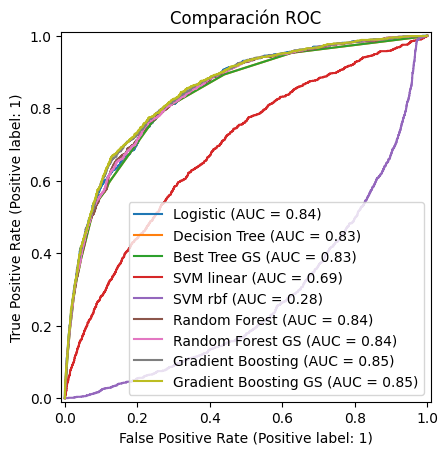

In [75]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test2, y_test, name="Logistic")
RocCurveDisplay.from_estimator(tree_clf, X_test, y_test, name="Decision Tree", ax=plt.gca())
RocCurveDisplay.from_estimator(best_tree, X_test, y_test, name="Best Tree GS", ax=plt.gca())
RocCurveDisplay.from_estimator(svm_linear, X_test2, y_test, name="SVM linear", ax=plt.gca())
RocCurveDisplay.from_estimator(svm_rbf, X_test2, y_test, name="SVM rbf", ax=plt.gca())
RocCurveDisplay.from_estimator(rnd_clf, X_test, y_test, name="Random Forest", ax=plt.gca())
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, name="Random Forest GS", ax=plt.gca())
RocCurveDisplay.from_estimator(gbct, X_test, y_test, name="Gradient Boosting", ax=plt.gca())
RocCurveDisplay.from_estimator(best_gb, X_test, y_test, name="Gradient Boosting GS", ax=plt.gca())
plt.title("Comparación ROC")
plt.show()

# FINAL:

ELIJO:
* Logistic (escalada): 0.8429491778917293
Decision Tree: 0.8337525932901095
Best Tree (GridSearch): 0.8337525932901095
Random Forest: 0.8420961938655763
Random Forest (tuned): 0.8420961938655763
Gradient Boosting: 0.8476738461054865
Gradient Boosting (tuned): 0.849262706096521

SI ELIJO ALGUNA DE LAS QUE ESTÁ ESCALADA, ANTES DE GUARDAR TENGO QUE VOLVER A TRANSFORMALO DE NUEVO HACIA ATRÁS:

In [ ]:
# X_kaggle = test.drop(columns=["ID"])
# X_kaggle = scaler.transform(X_kaggle)